# **Reconstruct the SM masking values via STAGE**

In [3]:
import scanpy as sc
import anndata
import pandas as pd
import STAGE
import SM2ST
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import pearsonr
os.environ['R_HOME'] = '/home/llx/software/minicbonda3/envs/pyg1/lib/R'

## **1 Read MSI**

In [8]:
# df_ms=pd.read_csv('/home/llx/project/jupyternotebook/1_pyg_backup/Data/MSD/mouse_brain_pen_dhb_50um_pixel_intensities.csv', skiprows=2,index_col=0)
df_ms=pd.read_csv('/home/llx/project/MSI_data/2025_2_21_mouse_brain/30um/ITO-PET-glass-30um_norm.csv',index_col=0)
df_ms

,x163_y1,x164_y1,x165_y1,x166_y1,x167_y1,x168_y1,x169_y1,x170_y1,x171_y1,x172_y1,...,x71_y170,x63_y171,x64_y171,x65_y171,x66_y171,x67_y171,x68_y171,x69_y171,x70_y171,x71_y171
152.021359,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
152.056053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,334.673097,...,0.000000,110.767004,182.607266,249.665533,244.559977,197.091889,213.577722,0.000000,0.00000,0.000000
154.024872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,151.295990,191.294577,0.000000,219.571437,133.958821,119.555462,0.000000,0.00000,169.058085
155.033100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,348.037274,...,497.200251,645.162779,732.514020,578.802570,808.645552,473.498011,556.023016,367.690765,486.14473,535.842891
156.040253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,138.091976,0.000000,0.000000,0.000000,0.000000,100.330463,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002.579091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1003.583304,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1006.496537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1020.535948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000


## **2 MSI constructs anndata**

In [9]:
def create_anndata_or(dataframe=None,pixel_size=1):
    df_ms_new=dataframe.iloc[:,:].T#4
    rows_all_zero = (df_ms_new == 0).all(axis=1)

    df_ms_new = df_ms_new[~rows_all_zero]
    df_ms_new = df_ms_new.apply(lambda x: x - x.min(), axis=0)
    rows = []
    cols = []
    for name in df_ms_new.index:
        x, y = name.split('_y')
        rows.append(int(x[1:]))
        cols.append(int(y))

    coordinates_df = pd.DataFrame({'array_row': rows, 'array_col': cols})
    coordinates_df.index = df_ms_new.index
    coordinates_physical_df = coordinates_df*pixel_size
    index_df = pd.DataFrame(index=dataframe.index)
    adata = anndata.AnnData(X=df_ms_new.values, obs=coordinates_df, var=index_df)#4
    adata.obsm['spatial'] = coordinates_physical_df.values
    return adata

In [10]:
adata = create_anndata_or(dataframe=df_ms,pixel_size=30)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


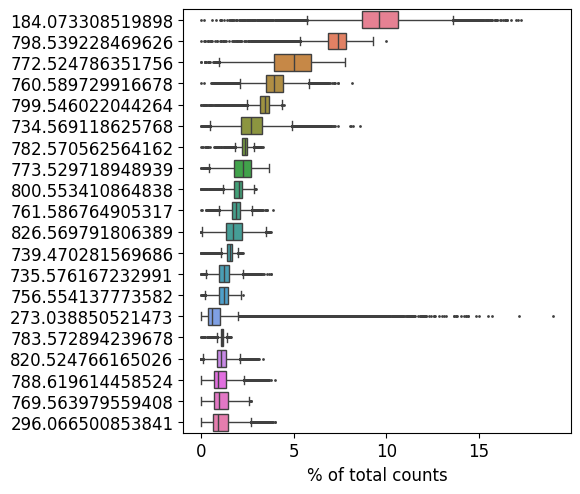

In [11]:
sc.pl.highest_expr_genes(adata, n_top=20, )

<Axes: title={'center': '159.00465933054'}, xlabel='spatial1', ylabel='spatial2'>

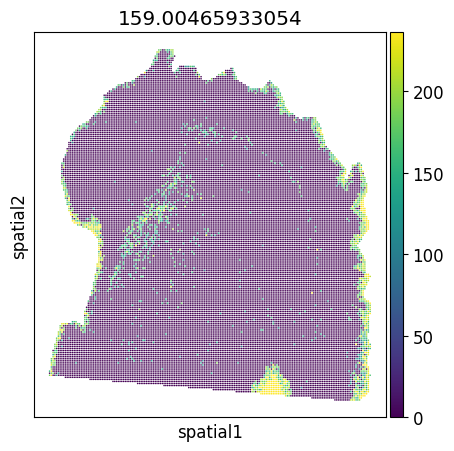

In [12]:
plot_gene = '159.00465933054'
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

<Axes: title={'center': '152.056052536344'}, xlabel='spatial1', ylabel='spatial2'>

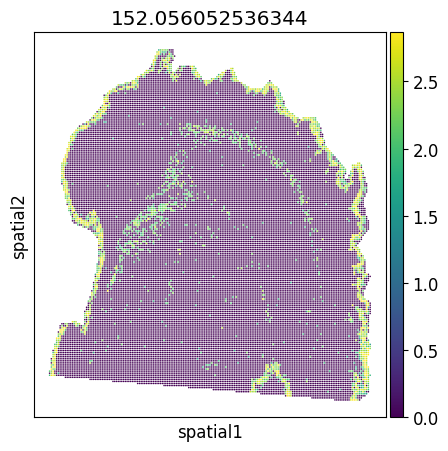

In [14]:
plot_gene = '152.056052536344'
fig, ax = plt.subplots(figsize=(5, 5)) 
plt.rcParams['font.size'] = 12 
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [15]:
adata.obsm['coord'] = adata.obsm['spatial']
# sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=1000)

## **3 Recovery the masked points**

In [1]:
adata_sample, adata_stage = STAGE.STAGE(adata=adata,train_epoch=10000,coord_sf=60,experiment='recovery')# 10_stage,30_sm2st_wo_wmse

<Axes: title={'center': '152.056052536344'}, xlabel='coord1', ylabel='coord2'>

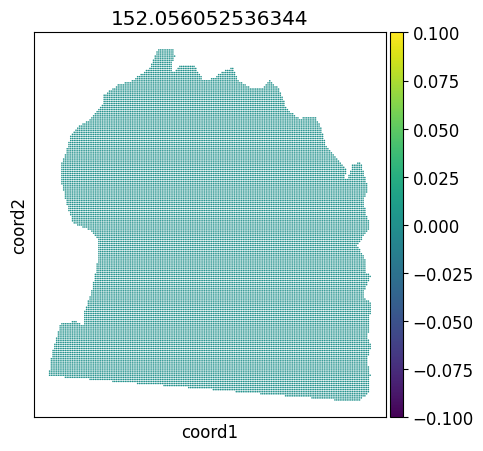

In [6]:
#new
plot_gene = '152.056052536344'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_stage, basis="coord", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '159.00465933054'}, xlabel='spatial1', ylabel='spatial2'>

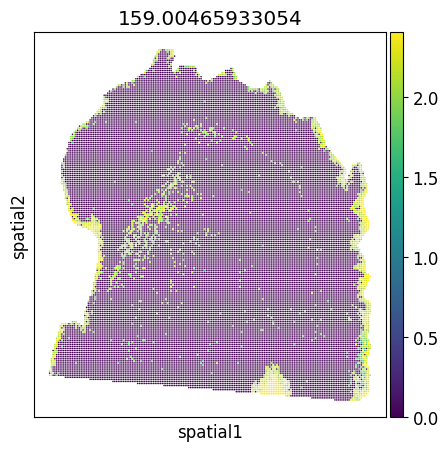

In [17]:
plot_gene = '159.00465933054'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '159.00465933054'}, xlabel='coord1', ylabel='coord2'>

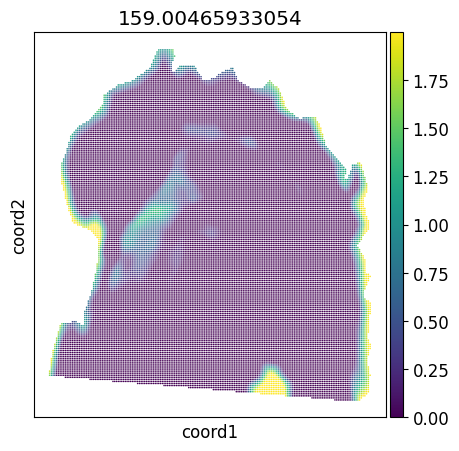

In [7]:
plot_gene = '159.00465933054'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(adata_stage, basis="coord", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.056052536344'}, xlabel='spatial1', ylabel='spatial2'>

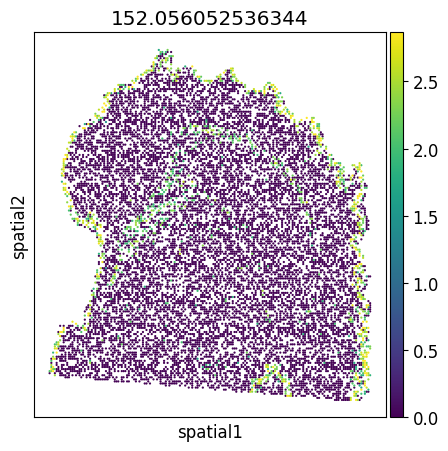

In [20]:
#new
plot_gene = '152.056052536344'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_sample, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [4]:
adata_stage = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLEDo_stage.h5ad')
adata_sample = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sampleo_stage.h5ad')

In [13]:
adata_SMLED2=sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLEDo.h5ad')
adata_sample2 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sampleo.h5ad')

## **4 Pearson correlation**

In [29]:
# Create mask: Keep the observations that are not in adata_sample
mask = ~adata_stage.obs_names.isin(adata_sample.obs_names)

In [31]:
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import pandas as pd

A = adata_stage[mask,:].X
B = adata[mask,:].X

r_values = []
p_values = []
for col1, col2 in zip(A, B):
    r_value, p_value = pearsonr(col1, col2)
    r_values.append(r_value)
    p_values.append(p_value)

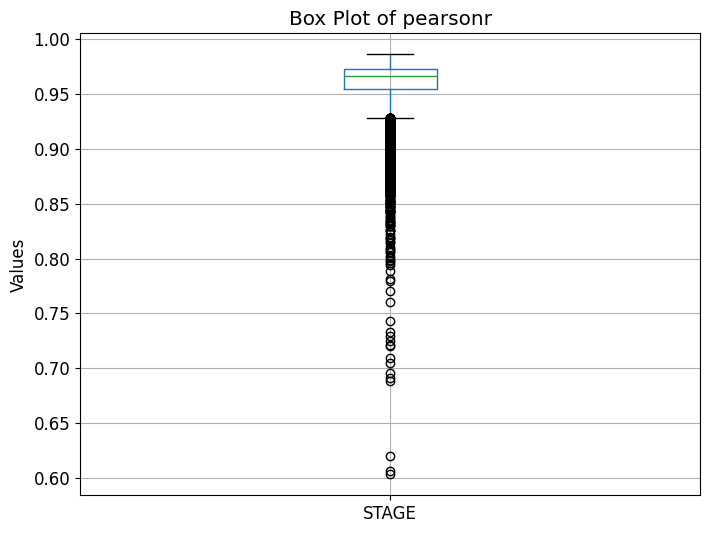

In [32]:
df = pd.DataFrame(r_values, columns=['STAGE'])

plt.figure(figsize=(8, 6)) 
df.boxplot()

plt.title('Box Plot of pearsonr')
plt.suptitle('') 
plt.xlabel('')#Columns
plt.ylabel('Values')

plt.show()

## **5 SSIM**

In [16]:
adata_stage.obsm['spatial'] = adata.obsm['spatial']

In [18]:
adata.obsm['spatial_tf'] = adata.obsm['spatial']//30
# adata.obsm['spatial_tf']
x_max = np.max(adata.obsm['spatial_tf'][:,0])
y_max = np.max(adata.obsm['spatial_tf'][:,1])
print(x_max,y_max)

183 171


In [20]:
# import numpy as np
# import anndata as ad
# from skimage.metrics import structural_similarity as ssim
# from scipy.sparse import issparse
# import matplotlib.pyplot as plt
# import seaborn as sns

# def adata_to_feature_images(adata, spatial_key='spatial_tf', image_shape=None):
#     """
#         Convert each feature in AnnData into a two-dimensional spatial image 
#         Parameters:
#         -----------
#         adata : AnnData
#         Including spatial coordinates (.obsm[spatial_key]) and expression matrix spatial_key : str
#         Key for spatial coordinates (default: 'spatial') image_shape : tuple
#         Image size (height, width). If set to None, it will be automatically determined. 
#         Return: -----------
#         feature_images : dict
#         {feature_name: 2D_image_array}
#     """
#     spatial_coords = adata.obsm[spatial_key]
    
#     # Convert to integer coordinates
#     if not np.issubdtype(spatial_coords.dtype, np.integer):
#         spatial_coords = np.round(spatial_coords).astype(int)
    
#     # Determine the image size
#     if image_shape is None:
#         max_x, max_y = spatial_coords[:, 0].max(), spatial_coords[:, 1].max()
#         image_shape = (max_y + 1, max_x + 1)  # (height, width)
    
#     height, width = image_shape
    
#     # Handling sparse matrices
#     X = adata.X
#     if issparse(X):
#         X = X.toarray()
    
#     # Create images for each feature
#     feature_images = {}
#     n_features = adata.shape[1]
    
#     print(f"Generating {n_features} features of images (shape: {image_shape})...")
    
#     for i, feature_name in enumerate(adata.var_names):
#         img = np.zeros(image_shape, dtype=np.float32)
        
#         # Map the expression values to spatial positions
#         x_coords = spatial_coords[:, 0]
#         y_coords = spatial_coords[:, 1]
        
#         # Ensure that the coordinates are within the boundaries
#         mask = (x_coords < width) & (y_coords < height)
#         x_valid = x_coords[mask]
#         y_valid = y_coords[mask]
#         values = X[mask, i]
        
#         # If multiple cells are mapped to the same location, take the average value
#         for x, y, val in zip(x_valid, y_valid, values):
#             if img[y, x] == 0:
#                 img[y, x] = val
#             else:
#                 # If there are duplicate positions, sum them up and then take the average of the subsequent values.
#                 img[y, x] += val
        
#         feature_images[feature_name] = img
    
#     return feature_images

# def calculate_spatial_feature_ssim(adata1, adata2, spatial_key='spatial_tf', 
#                                    image_shape=(171, 183), win_size=3):
#     """
#         Calculate the SSIM (Structural Similarity Index Measure) for each feature in the spatial dimension of the two AnnData datasets. 
#         Parameters:
#         -----------
#         adata1, adata2 : AnnData
#         Two datasets (which must have the same spatial coordinates and features) spatial_key : str
#         Storage key for spatial coordinates image_shape : tuple
#         Output image size (height = 171, width = 183) win_size : int
#         The size of the SSIM window must be an odd number and must be less than or equal to the minimum value of the image shape. 
#         Return: -----------
#         ssim_scores : dict
#         {feature_name: ssim_score}
#     """
#     common_features = np.intersect1d(adata1.var_names, adata2.var_names)
#     if len(common_features) == 0:
#         raise ValueError("The two sets of data do not share any common features.")
    
#     coord1 = adata1.obsm[spatial_key]
#     coord2 = adata2.obsm[spatial_key]
#     if not np.array_equal(coord1, coord2):
#         print("⚠️ Warning: The spatial coordinates of the two sets of data are not completely consistent, and the results may not be reliable.")
    
#     # Generate image
#     print("The image of the first set of data is being generated...")
#     images1 = adata_to_feature_images(adata1, spatial_key, image_shape)
    
#     print("The image of the second set of data is currently being generated...")
#     images2 = adata_to_feature_images(adata2, spatial_key, image_shape)
    
#     # Calculate the SSIM for each feature
#     ssim_scores = {}
#     print(f"Calculating the SSIM for {len(common_features)} features...")
    
#     # Check whether the win_size is appropriate
#     min_dim = min(image_shape)
#     if win_size > min_dim:
#         win_size = min_dim if min_dim % 2 == 1 else min_dim - 1
#         print(f"⚠️ Automatically adjust win_size to: {win_size}")
    
#     for idx, feature in enumerate(common_features):
#         img1 = images1[feature]
#         img2 = images2[feature]
        
#         # Calculate the dynamic data range
#         data_range = max(img1.max() - img1.min(), img2.max() - img2.min())
        
#         # If the data range is zero (meaning the values are exactly the same)
#         if data_range == 0:
#             ssim_scores[feature] = 1.0  # 
#             continue
        
#         try:
#             score = ssim(
#                 img1, img2,
#                 data_range=data_range,
#                 win_size=win_size,
#                 channel_axis=None
#             )
#             ssim_scores[feature] = score
#         except Exception as e:
#             print(f"Calculation of {feature} failed: {e}")
#             ssim_scores[feature] = np.nan
        
#         if (idx + 1) % 100 == 0:
#             print(f"  finish{idx + 1}/{len(common_features)} features")
    
#     print(f"finish！AverageSSIM: {np.nanmean(list(ssim_scores.values())):.4f}")
#     return ssim_scores

# def visualize_feature_spatial(adata1, adata2, feature_name, spatial_key='spatial_tf', 
#                               image_shape=(171, 183), ssim_scores=None):
#     """
#     Visualize the spatial distribution and differences of a specific feature in the two data sets
#     """
#     images1 = adata_to_feature_images(adata1, spatial_key, image_shape)
#     images2 = adata_to_feature_images(adata2, spatial_key, image_shape)
    
#     fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
#     # data1
#     im1 = axes[0].imshow(images1[feature_name], cmap='magma')
#     axes[0].set_title(f'adata - {feature_name}')
#     plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
#     # data2
#     im2 = axes[1].imshow(images2[feature_name], cmap='magma')
#     axes[1].set_title(f'adata_SMLED2 - {feature_name}')
#     plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
#     # Difference image
#     diff = images1[feature_name] - images2[feature_name]
#     im3 = axes[2].imshow(diff, cmap='RdBu_r')
#     axes[2].set_title(f'Difference (SSIM: {ssim_scores[feature_name]:.4f})')
#     plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
#     for ax in axes:
#         ax.set_xlabel('X')
#         ax.set_ylabel('Y')
    
#     plt.tight_layout()
#     plt.show()

In [21]:
adata_stage.obsm['spatial_tf'] = adata_stage.obsm['coord']//30
adata.obsm['spatial_tf'] = adata.obsm['coord']//30

In [22]:
adata_stage.obsm['spatial'] = adata_stage.obsm['coord']

In [23]:
import squidpy as sq
sq.gr.spatial_neighbors(adata_stage)
sq.gr.spatial_autocorr(adata_stage, mode="moran", genes=adata_stage.var_names)
sq.gr.spatial_autocorr(adata_stage, mode="geary", genes=adata_stage.var_names)

sq.gr.spatial_neighbors(adata)
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 875 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 875 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 155 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 155 variables were constant, will return nan for these.
  warnings.warn(


In [24]:
ms_adata_high_moran_genes = adata.uns['moranI']['I'][(adata.uns['moranI']['I'] > 0.15) & (adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_moran = adata[:, ms_adata_high_moran_genes]

ms_adata_high_geary_genes = adata.uns['gearyC']['C'][(adata.uns['gearyC']['C'] < 0.7) & (adata.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_geary = adata[:, ms_adata_high_geary_genes]

In [25]:
adata_SMLED_high_moran_genes = adata_stage.uns['moranI']['I'][(adata_stage.uns['moranI']['I'] > 0.15) & (adata_stage.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_moran = adata_stage[:, adata_SMLED_high_moran_genes]

adata_SMLED_high_geary_genes = adata_stage.uns['gearyC']['C'][(adata_stage.uns['gearyC']['C'] < 0.7) & (adata_stage.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_geary = adata_stage[:, adata_SMLED_high_geary_genes]

In [26]:
ms_adata_set1 = set(ms_adata_high_geary.var_names)
ms_adata_set2 = set(ms_adata_high_moran.var_names)
ms_adata_v = ms_adata_set1&ms_adata_set2

In [27]:
adata_SMLED_set1 = set(adata_SMLED_high_geary.var_names)
adata_SMLED_set2 = set(adata_SMLED_high_moran.var_names)
adata_SMLED_v = adata_SMLED_set1&adata_SMLED_set2

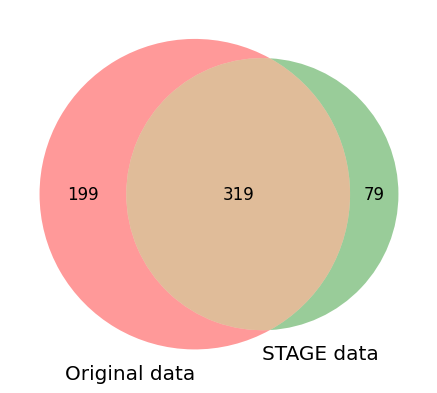

In [28]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

set1 = ms_adata_v
set2 = adata_SMLED_v

venn = venn2([set1, set2], ('Original data', 'STAGE data'))

venn.get_label_by_id('100').set_text(f'{len(set1 - set2)}')
venn.get_label_by_id('010').set_text(f'{len(set2 - set1)}')
venn.get_label_by_id('110').set_text(f'{len(set1 & set2)}')

plt.show()

In [34]:
gene = adata_stage.var_names.isin(ms_adata_v)

In [35]:
adata_stage.obsm['spatial_tf'] = adata_stage.obsm['coord']//30
adata.obsm['spatial_tf'] = adata.obsm['spatial']//30
# check data
print(f"adata shape: {adata.shape}")
print(f"adata_stage shape: {adata_stage.shape}")
print(f"Coordinate range: x={adata.obsm['spatial_tf'][:,0].max()}, y={adata.obsm['spatial_tf'][:,1].max()}")

# SSIM
ssim_results_stage = SM2ST.calculate_spatial_feature_ssim(
    adata[:,gene], 
    adata_stage[:,gene],
    spatial_key='spatial_tf',
    image_shape=(171, 183),  # (height, width)
    win_size=7
)

scores_stage = list(ssim_results_stage.values())
print(f"\nSSIM statistical information:")
print(f"  Average value: {np.mean(scores_stage):.4f}")
print(f"  Median: {np.median(scores_stage):.4f}")
print(f"  Standard deviation: {np.std(scores_stage):.4f}")
print(f"  min: {np.min(scores_stage):.4f}")
print(f"  max: {np.max(scores_stage):.4f}")

adata shape: (23626, 1273)
adata_stage shape: (23626, 1273)
Coordinate range: x=183, y=171
The image of the first set of data is being generated...
Generating 518 features of images (shape: (171, 183))...
The image of the second set of data is currently being generated...
Generating 518 features of images (shape: (171, 183))...
Calculating the SSIM for 518 features...
  finish100/518 features
  finish200/518 features
  finish300/518 features
  finish400/518 features
  finish500/518 features
finish！AverageSSIM: 0.6917

SSIM statistical information:
  Average value: 0.6917
  Median: 0.7227
  Standard deviation: 0.2211
  min: 0.1865
  max: 0.9986
